# Exp 10: Custom CNN + Bi-GRU + Self-Attention Transformer

**Goal:** Same custom CNN + Bi-GRU backbone as Exp 9, but replace the FCNN fusion with self-attention over the combined image and text representations.

**Architecture:**
```
Image → CNN Encoder → spatial features [B, 196, 256]  (14x14 patches)
Text  → Embedding → Bi-GRU → hidden states [B, seq, 256]
      → Concat token sequences [B, 196+seq, 256]
      → Self-Attention Transformer (2 layers)
      → Mean pool → Linear → 1
```

**Key difference from Exp 9:** Instead of pooling image/text into single vectors, we keep the spatial/sequential structure and let self-attention find relationships within and across both modalities jointly.

In [ ]:
!pip install -q jsonlines

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from PIL import Image
from sklearn.metrics import roc_auc_score, accuracy_score, classification_report
import matplotlib.pyplot as plt
import json, copy, os
import jsonlines
import warnings
warnings.filterwarnings('ignore')

In [ ]:
import kagglehub, shutil, os, sys
from pathlib import Path

# Download dataset to Colab SSD (much faster than Drive FUSE)
path = kagglehub.dataset_download("parthplc/facebook-hateful-meme-dataset")
print("Downloaded to:", path)

for root, dirs, files in os.walk(path):
    for f in files[:5]:
        print(os.path.join(root, f))

100%|██████████| 3.35G/3.35G [00:32<00:00, 111MB/s] 

Extracting files...


Downloaded to: /root/.cache/kagglehub/datasets/parthplc/facebook-hateful-meme-dataset/versions/1
/root/.cache/kagglehub/datasets/parthplc/facebook-hateful-meme-dataset/versions/1/data/train.jsonl
/root/.cache/kagglehub/datasets/parthplc/facebook-hateful-meme-dataset/versions/1/data/dev.jsonl
/root/.cache/kagglehub/datasets/parthplc/facebook-hateful-meme-dataset/versions/1/data/README.md
/root/.cache/kagglehub/datasets/parthplc/facebook-hateful-meme-dataset/versions/1/data/LICENSE.txt
/root/.cache/kagglehub/datasets/parthplc/facebook-hateful-meme-dataset/versions/1/data/test.jsonl
/root/.cache/kagglehub/datasets/parthplc/facebook-hateful-meme-dataset/versions/1/data/img/40723.png
/root/.cache/kagglehub/datasets/parthplc/facebook-hateful-meme-dataset/versions/1/data/img/83476.png
/root/.cache/kagglehub/datasets/parthplc/facebook-hateful-meme-dataset/versions/1/data/img/48039.png
/root/.cache/kagglehub/datasets/parthplc/facebook-hateful-meme-dataset/versions/1/data/img/56281.png
/root/.ca

In [ ]:
ROOT    = Path(path) / 'data'
IMG_DIR = ROOT / 'img'

RESULTS_DIR = 'content/results'
MODELS_DIR  = 'content/models'
OUTPUTS_DIR = 'content/outputs'

os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(MODELS_DIR,  exist_ok=True)
os.makedirs(OUTPUTS_DIR, exist_ok=True)

print(f'ROOT   : {ROOT}')
print(f'IMG_DIR: {IMG_DIR}')

ROOT   : /root/.cache/kagglehub/datasets/parthplc/facebook-hateful-meme-dataset/versions/1/data
IMG_DIR: /root/.cache/kagglehub/datasets/parthplc/facebook-hateful-meme-dataset/versions/1/data/img


In [ ]:
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')
if DEVICE == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

Device: cuda
GPU: Tesla T4
VRAM: 15.6 GB


## 1. Load Data & Vocab (from Exp 9)

In [ ]:
def load_jsonl(path):
    data = []
    with jsonlines.open(path) as reader:
        for item in reader: data.append(item)
    return data

train_data = load_jsonl(ROOT / 'train.jsonl')
dev_data   = load_jsonl(ROOT / 'dev.jsonl')

# Load vocab saved by Exp 9
assert os.path.exists('content/results/vocab.json'), 'Run exp9 first to generate vocab.json!'
vocab_data = json.load(open('content/results/vocab.json'))
word2idx   = vocab_data['word2idx']
VOCAB_SIZE = vocab_data['vocab_size']
PAD_IDX    = vocab_data['pad_idx']
UNK_IDX    = vocab_data['unk_idx']
print(f'Train: {len(train_data)} | Dev: {len(dev_data)} | Vocab: {VOCAB_SIZE}')

Train: 8500 | Dev: 500 | Vocab: 5829


## 2. Dataset

In [ ]:
MAX_LEN  = 32
IMG_SIZE = 224
FEAT_DIM = 256  # shared dim for image patches and text tokens

img_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

def simple_tokenize(text): return text.lower().split()

def encode_text(text, max_len=MAX_LEN):
    tokens = simple_tokenize(text)[:max_len]
    ids    = [word2idx.get(t, UNK_IDX) for t in tokens]
    ids   += [PAD_IDX] * (max_len - len(ids))
    return ids

class HatefulMemesDataset(Dataset):
    def __init__(self, data, img_dir, transform):
        self.data      = data
        self.img_dir   = Path(img_dir)
        self.transform = transform

    def __len__(self): return len(self.data)

    def __getitem__(self, idx):
        item    = self.data[idx]
        image   = Image.open(self.img_dir / item['img'].split('/')[-1]).convert('RGB')
        img_t   = self.transform(image)
        text_t  = torch.tensor(encode_text(item['text']), dtype=torch.long)
        txt_pad_mask = (text_t == PAD_IDX)  # True where padded
        label   = torch.tensor(item['label'], dtype=torch.float32)
        return img_t, text_t, txt_pad_mask, label

BATCH_SIZE   = 32  # smaller — self-attention over long sequences is memory heavy
train_ds     = HatefulMemesDataset(train_data, IMG_DIR, img_transform)
dev_ds       = HatefulMemesDataset(dev_data,   IMG_DIR, img_transform)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
dev_loader   = DataLoader(dev_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

n_pos      = sum(d['label'] for d in train_data)
n_neg      = len(train_data) - n_pos
pos_weight = torch.tensor([n_neg / n_pos], dtype=torch.float32).to(DEVICE)
print(f'Train batches: {len(train_loader)} | Dev batches: {len(dev_loader)}')
print(f'pos_weight: {pos_weight.item():.3f}')

Train batches: 266 | Dev batches: 16
pos_weight: 1.787


## 3. Model — CNN + Bi-GRU + Self-Attention

### Key architectural change from Exp 9:
- CNN now outputs **spatial feature map** (14×14=196 patch vectors) instead of a single GAP vector
- Bi-GRU outputs **all hidden states** (seq_len vectors) instead of just the final state
- Both projected to same `FEAT_DIM=256`
- Concatenated into a single sequence `[196 + seq_len, 256]`
- **Self-attention transformer** processes this joint sequence — tokens attend to both image patches and other text tokens
- Mean pool over all tokens → classifier

In [ ]:
class CNNPatchEncoder(nn.Module):
    """CNN that outputs spatial patch features instead of a single vector."""
    def __init__(self, feat_dim=256):
        super().__init__()
        def conv_block(in_ch, out_ch):
            return nn.Sequential(
                nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1),
                nn.BatchNorm2d(out_ch),
                nn.ReLU(inplace=True),
                nn.MaxPool2d(2)
            )
        self.features = nn.Sequential(
            conv_block(3,   32),
            conv_block(32,  64),
            conv_block(64, 128),
            conv_block(128, 256),
        )  # 224->112->56->28->14 spatial
        self.proj = nn.Linear(256, feat_dim)

    def forward(self, x):
        x = self.features(x)                         # [B, 256, 14, 14]
        B, C, H, W = x.shape
        x = x.flatten(2).transpose(1, 2)             # [B, 196, 256]
        return self.proj(x)                           # [B, 196, feat_dim]


class BiGRUEncoder(nn.Module):
    """Bi-GRU that outputs all hidden states (not just final)."""
    def __init__(self, vocab_size, embed_dim=128, hidden_dim=128,
                 feat_dim=256, pad_idx=0, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.gru       = nn.GRU(embed_dim, hidden_dim, bidirectional=True, batch_first=True)
        self.dropout   = nn.Dropout(dropout)
        self.proj      = nn.Linear(hidden_dim * 2, feat_dim)

    def forward(self, token_ids):
        emb  = self.dropout(self.embedding(token_ids))  # [B, seq, embed_dim]
        out, _ = self.gru(emb)                          # [B, seq, 2*hidden_dim]
        return self.proj(self.dropout(out))              # [B, seq, feat_dim]


class SelfAttentionFusion(nn.Module):
    """Self-attention transformer over joint image+text token sequence."""
    def __init__(self, feat_dim=256, nhead=8, num_layers=2, dropout=0.1):
        super().__init__()
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=feat_dim, nhead=nhead,
            dim_feedforward=feat_dim * 4,
            dropout=dropout, batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

    def forward(self, x, src_key_padding_mask=None):
        return self.transformer(x, src_key_padding_mask=src_key_padding_mask)


class CNNBiGRUSelfAttn(nn.Module):
    def __init__(self, vocab_size, pad_idx, feat_dim=256,
                 nhead=8, num_layers=2, dropout=0.3):
        super().__init__()
        self.cnn_encoder  = CNNPatchEncoder(feat_dim=feat_dim)
        self.gru_encoder  = BiGRUEncoder(vocab_size, feat_dim=feat_dim,
                                          pad_idx=pad_idx, dropout=dropout)
        self.self_attn    = SelfAttentionFusion(feat_dim=feat_dim, nhead=nhead,
                                                 num_layers=num_layers, dropout=dropout)
        self.classifier   = nn.Sequential(
            nn.Linear(feat_dim, feat_dim // 2), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(feat_dim // 2, 1)
        )

    def forward(self, images, token_ids, txt_pad_mask):
        img_tokens = self.cnn_encoder(images)          # [B, 196, feat_dim]
        txt_tokens = self.gru_encoder(token_ids)        # [B, seq, feat_dim]

        # img tokens are never padded; txt tokens may be
        B = images.size(0)
        img_pad_mask = torch.zeros(B, img_tokens.size(1),
                                    dtype=torch.bool, device=DEVICE)  # [B, 196]
        joint_pad_mask = torch.cat([img_pad_mask, txt_pad_mask], dim=1)  # [B, 196+seq]

        joint = torch.cat([img_tokens, txt_tokens], dim=1)  # [B, 196+seq, feat_dim]
        out   = self.self_attn(joint, src_key_padding_mask=joint_pad_mask)

        # Mean pool over non-padded tokens
        mask_float = (~joint_pad_mask).float().unsqueeze(-1)  # [B, 196+seq, 1]
        pooled     = (out * mask_float).sum(1) / mask_float.sum(1).clamp(min=1)

        return self.classifier(pooled).squeeze(-1)


model = CNNBiGRUSelfAttn(vocab_size=VOCAB_SIZE, pad_idx=PAD_IDX).to(DEVICE)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Trainable params: {n_params:,}')

Trainable params: 3,077,761


## 4. Optimizer & Scheduler

In [ ]:
EPOCHS    = 20
PATIENCE  = 5
LR        = 1e-4

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)

print(f'Epochs: {EPOCHS} | LR: {LR} | Patience: {PATIENCE}')

Epochs: 20 | LR: 0.0001 | Patience: 5


## 5. Training Loop

In [ ]:
from torch.cuda.amp import autocast, GradScaler
scaler = GradScaler()

def run_epoch(loader, model, criterion, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()
    total_loss, all_probs, all_labels = 0.0, [], []

    for images, token_ids, txt_pad_mask, y in loader:
        images       = images.to(DEVICE)
        token_ids    = token_ids.to(DEVICE)
        txt_pad_mask = txt_pad_mask.to(DEVICE)
        y            = y.to(DEVICE)

        with autocast():
            logits = model(images, token_ids, txt_pad_mask)
            loss   = criterion(logits, y)

        if is_train:
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad()

        total_loss += loss.item() * len(y)
        all_probs.extend(torch.sigmoid(logits).detach().float().cpu().numpy())
        all_labels.extend(y.cpu().numpy())

    auc = roc_auc_score(all_labels, all_probs)
    acc = accuracy_score(all_labels, (np.array(all_probs) >= 0.5).astype(int))
    return total_loss / len(all_labels), auc, acc, np.array(all_probs), np.array(all_labels)


history = {'train_loss': [], 'dev_loss': [], 'train_auc': [], 'dev_auc': []}
best_dev_auc, best_state, patience_ctr = 0.0, None, 0

exp9_auc = json.load(open('content/results/exp9.json'))['results']['dev_auc_roc']
print('Training: CNN + Bi-GRU + Self-Attention (all from scratch)')
print('=' * 60)

for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_auc, tr_acc, _, _ = run_epoch(train_loader, model, criterion, optimizer)
    dv_loss, dv_auc, dv_acc, _, _ = run_epoch(dev_loader,   model, criterion)
    scheduler.step()

    history['train_loss'].append(tr_loss); history['dev_loss'].append(dv_loss)
    history['train_auc'].append(tr_auc);   history['dev_auc'].append(dv_auc)

    if dv_auc > best_dev_auc:
        best_dev_auc = dv_auc; best_state = copy.deepcopy(model.state_dict())
        patience_ctr = 0; flag = '  <- best'
    else:
        patience_ctr += 1; flag = f'  (patience {patience_ctr}/{PATIENCE})'

    print(f'Ep {epoch:02d} | Tr Loss {tr_loss:.4f} AUC {tr_auc:.4f} Acc {tr_acc:.4f} | '
          f'Dev Loss {dv_loss:.4f} AUC {dv_auc:.4f} Acc {dv_acc:.4f}{flag}')

    if patience_ctr >= PATIENCE:
        print(f'Early stopping at epoch {epoch}'); break

model.load_state_dict(best_state)
print(f'\nBest Dev AUC  : {best_dev_auc:.4f}')
print(f'Exp 9 baseline: {exp9_auc:.4f}')
print(f'Self-attn delta: {best_dev_auc - exp9_auc:+.4f}')

Training: CNN + Bi-GRU + Self-Attention (all from scratch)
Ep 01 | Tr Loss 0.8867 AUC 0.5515 Acc 0.5436 | Dev Loss 1.0265 AUC 0.4929 Acc 0.4920  <- best
Ep 02 | Tr Loss 0.8728 AUC 0.5915 Acc 0.5734 | Dev Loss 0.9405 AUC 0.4956 Acc 0.4900  <- best
Ep 03 | Tr Loss 0.8399 AUC 0.6580 Acc 0.6206 | Dev Loss 0.9987 AUC 0.5573 Acc 0.5560  <- best
Ep 04 | Tr Loss 0.8170 AUC 0.6892 Acc 0.6478 | Dev Loss 1.0816 AUC 0.5377 Acc 0.5260  (patience 1/5)
Ep 05 | Tr Loss 0.7982 AUC 0.7107 Acc 0.6699 | Dev Loss 1.0614 AUC 0.5611 Acc 0.5400  <- best
Ep 06 | Tr Loss 0.7874 AUC 0.7226 Acc 0.6771 | Dev Loss 1.0466 AUC 0.5518 Acc 0.5300  (patience 1/5)
Ep 07 | Tr Loss 0.7682 AUC 0.7442 Acc 0.6872 | Dev Loss 0.9721 AUC 0.5615 Acc 0.5360  <- best
Ep 08 | Tr Loss 0.7567 AUC 0.7518 Acc 0.6935 | Dev Loss 1.0298 AUC 0.5632 Acc 0.5260  <- best
Ep 09 | Tr Loss 0.7325 AUC 0.7730 Acc 0.7074 | Dev Loss 1.0019 AUC 0.5762 Acc 0.5380  <- best
Ep 10 | Tr Loss 0.7188 AUC 0.7840 Acc 0.7228 | Dev Loss 1.0353 AUC 0.5817 Acc 0.5

## 6. Training Curves

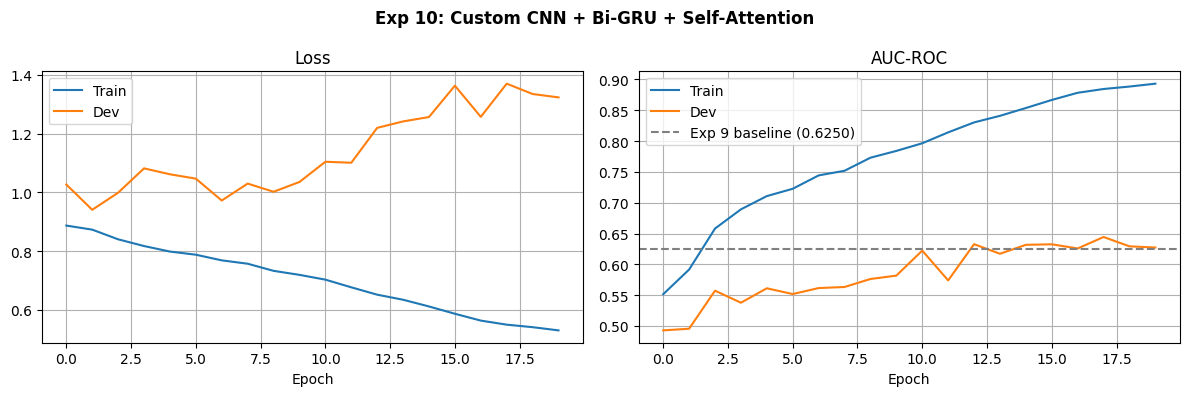

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history['train_loss'], label='Train'); axes[0].plot(history['dev_loss'], label='Dev')
axes[0].set_title('Loss'); axes[0].set_xlabel('Epoch'); axes[0].legend(); axes[0].grid(True)
axes[1].plot(history['train_auc'], label='Train'); axes[1].plot(history['dev_auc'], label='Dev')
axes[1].axhline(exp9_auc, color='gray', linestyle='--', label=f'Exp 9 baseline ({exp9_auc:.4f})')
axes[1].set_title('AUC-ROC'); axes[1].set_xlabel('Epoch'); axes[1].legend(); axes[1].grid(True)
plt.suptitle('Exp 10: Custom CNN + Bi-GRU + Self-Attention', fontweight='bold')
plt.tight_layout()
plt.savefig('content/outputs/10_training_curves.png', dpi=150)
plt.show()

## 7. Evaluate & Save

In [ ]:
_, dev_auc, dev_acc, dev_probs, dev_true = run_epoch(dev_loader, model, criterion)
dev_preds = (dev_probs >= 0.5).astype(int)
print('=' * 55)
print('EXP 10 — CNN + Bi-GRU + Self-Attention | Dev Set')
print('=' * 55)
print(f'AUC-ROC  : {dev_auc:.4f}')
print(f'Accuracy : {dev_acc:.4f}')
print()
print(classification_report(dev_true, dev_preds, target_names=['Not Hateful', 'Hateful']))

torch.save(best_state, 'content/models/10_cnn_bigru_self_attn.pt')

exp10_out = {
    'experiment': '10_CNN_BiGRU_SelfAttention',
    'pipeline': 'CNN patches [196] + BiGRU hidden states [seq] -> concat -> Self-Attention -> mean pool -> classifier',
    'pretrained': False,
    'results': {'dev_auc_roc': round(float(dev_auc), 4), 'dev_accuracy': round(float(dev_acc), 4)},
    'architecture': {
        'cnn': '4 conv blocks + flatten to 196 patch tokens + Linear(256)',
        'bigru': 'Embedding + BiGRU -> all hidden states + Linear(256)',
        'self_attention': 'TransformerEncoder(d=256, nhead=8, layers=2) over joint [196+32] tokens',
        'classifier': 'mean pool -> Linear(128) -> Linear(1)'
    }
}
with open('content/results/exp10.json', 'w') as f:
    json.dump(exp10_out, f, indent=2)

print('Model   -> content/models/10_cnn_bigru_self_attn.pt')
print('Results -> content/results/exp10.json')
print(json.dumps(exp10_out, indent=2))

EXP 10 — CNN + Bi-GRU + Self-Attention | Dev Set
AUC-ROC  : 0.6443
Accuracy : 0.5900

              precision    recall  f1-score   support

 Not Hateful       0.56      0.83      0.67       250
     Hateful       0.67      0.35      0.46       250

    accuracy                           0.59       500
   macro avg       0.62      0.59      0.56       500
weighted avg       0.62      0.59      0.56       500

Model   -> content/models/10_cnn_bigru_self_attn.pt
Results -> content/results/exp10.json
{
  "experiment": "10_CNN_BiGRU_SelfAttention",
  "pipeline": "CNN patches [196] + BiGRU hidden states [seq] -> concat -> Self-Attention -> mean pool -> classifier",
  "pretrained": false,
  "results": {
    "dev_auc_roc": 0.6443,
    "dev_accuracy": 0.59
  },
  "architecture": {
    "cnn": "4 conv blocks + flatten to 196 patch tokens + Linear(256)",
    "bigru": "Embedding + BiGRU -> all hidden states + Linear(256)",
    "self_attention": "TransformerEncoder(d=256, nhead=8, layers=2) over jo